#### Build a model to find whether the person will be defaulter for loan or not when income & balance of the person is provided

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/Default.csv")
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [3]:
data.shape

(10000, 4)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [5]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462905
50%,823.636973,34552.644800
75%,1166.308387,43807.729275
max,2654.322576,73554.233500


{'whiskers': [<matplotlib.lines.Line2D at 0x1d1c974ca50>,
 'caps': [<matplotlib.lines.Line2D at 0x1d1c9774e10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d1c974e490>],
 'medians': [<matplotlib.lines.Line2D at 0x1d1c9775090>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d1c97751d0>],
 'means': []}

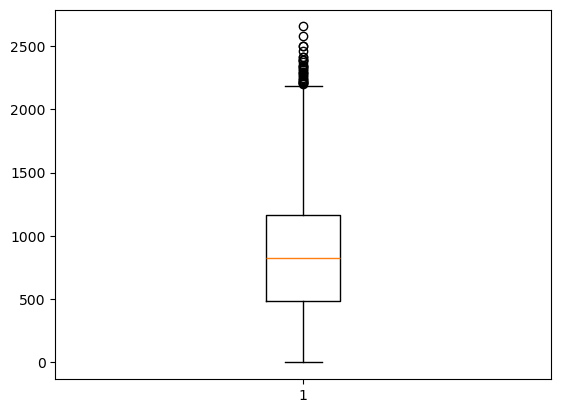

In [6]:
plt.boxplot(data['balance'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1d1c9f99e50>,
 'caps': [<matplotlib.lines.Line2D at 0x1d1c9f9a0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d1c9f99d10>],
 'medians': [<matplotlib.lines.Line2D at 0x1d1c9f9a350>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d1c9f9a490>],
 'means': []}

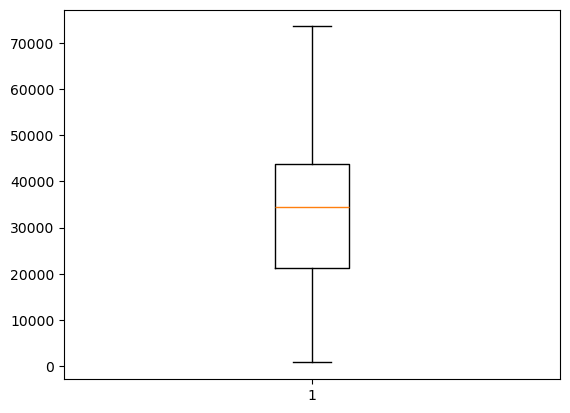

In [7]:
plt.boxplot(data['income'])

In [8]:
mean_bal = data['balance'].mean()
mean_bal

np.float64(835.3748856149443)

In [9]:
std_bal = data['balance'].std()
std_bal

483.71498521033266

In [10]:
data[data['balance']>(mean_bal + 3 * std_bal)].shape[0]

20

In [11]:
data.drop(data[data['balance']>(mean_bal + 3 * std_bal)].index,inplace = True)

In [12]:
data.shape

(9980, 4)

In [13]:
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [14]:
data.drop(['student'],axis = 1,inplace = True)

In [15]:
data.head()

,default,balance,income
0,No,729.526495,44361.62507
1,No,817.180407,12106.13470
2,No,1073.549164,31767.13895
3,No,529.250605,35704.49394
4,No,785.655883,38463.49588


In [16]:
X = data.drop(['default'],axis = 1)
y = data['default']

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

In [19]:
X_scaler = scaler.fit_transform(X)

In [20]:
X_scaler

array([[-0.21441333,  0.81242977],
       [-0.03144945, -1.60711735],
       [ 0.50368037, -0.13230715],
       ...,
       [ 0.02747958,  1.8831902 ],
       [ 1.53787566,  0.23539942],
       [-1.31779244, -1.2502992 ]])

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X_scaler,y,test_size = 0.2,random_state = 10)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 15)

In [24]:
model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=15)

In [25]:
test_predict = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
accuracy_score(y_test,test_predict)

0.9759519038076152

#### Hyper parameters(n_neighbor) tunning

In [28]:
train_acc = []
test_acc = []
n_neighbors = []
for k in range(3,16,2):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train,y_train)
    test_predict = model.predict(X_test)
    train_predict = model.predict(X_train)
    te_acc = accuracy_score(y_test,test_predict)
    tr_acc = accuracy_score(y_train,train_predict)
    n_neighbors.append(k)
    train_acc.append(tr_acc)
    test_acc.append(te_acc)

In [29]:
train_acc

[0.9770791583166333,
 0.9739478957915831,
 0.9746993987975952,
 0.9745741482965932,
 0.9745741482965932,
 0.9736973947895792,
 0.9739478957915831]

In [30]:
test_acc

[0.967434869739479,
 0.9694388777555111,
 0.9714428857715431,
 0.9744488977955912,
 0.9744488977955912,
 0.9749498997995992,
 0.9759519038076152]

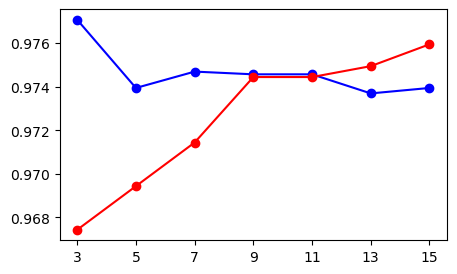

In [31]:
plt.figure(figsize = (5,3))
plt.plot(n_neighbors,train_acc,marker='o',color = 'blue')
plt.plot(n_neighbors,test_acc,marker='o',color = 'red')
plt.xticks(n_neighbors)
plt.show()

#### Confusion Metrics

In [32]:
from sklearn.metrics import confusion_matrix
res = confusion_matrix(y_test,test_predict)
res

array([[1924,    9],
       [  39,   24]])

In [33]:
pd.DataFrame(res,columns = ['predicted +ve','predicted -ve'],index = ['actual +ve','actual -ve'])

,predicted +ve,predicted -ve
actual +ve,1924,9
actual -ve,39,24


In [34]:
from sklearn.metrics import precision_score,recall_score

In [35]:
precision_score(y_test,test_predict,pos_label = 'No')

0.9801324503311258

In [36]:
1924 / (1924 + 39)

0.9801324503311258

In [37]:
recall_score(y_test,test_predict,pos_label = 'No')

0.9953440248318676

In [38]:
1924 / (1924 + 9)

0.9953440248318676

In [39]:
precision_score(y_test,test_predict,pos_label = 'Yes')

0.7272727272727273

In [40]:
recall_score(y_test,test_predict,pos_label = 'Yes')

0.38095238095238093

#### Cross Validation

In [41]:
from sklearn.model_selection import cross_validate

In [42]:
result = cross_validate(model,X_train,y_train,cv = 5)

In [43]:
result

{'fit_time': array([0.02715993, 0.01886153, 0.01476598, 0.02498555, 0.01504731]),
 'score_time': array([0.21782827, 0.21097517, 0.1917212 , 0.21574998, 0.21877718]),
 'test_score': array([0.97056982, 0.97432686, 0.97119599, 0.97182217, 0.97556391])}

In [44]:
print('Validation Score:',result['test_score'].mean())

Validation Score: 0.9726957500200093
